Setup and Clone

In [1]:
"""
import os

%cd /content

repo_name = "Detecting-LLM-Generated-Social-Media-Accounts-Using-Semantic-and-Textual"
if not os.path.exists(repo_name):
  !git clone https://github.com/ayiii-a/Detecting-LLM-Generated-Social-Media-Accounts-Using-Semantic-and-Textual.git


%cd /content/{repo_name}

from google.colab import drive
drive.mount('/content/drive')

os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"

!pip install -q transformers accelerate
"""

'\nimport os\n\n%cd /content\n\nrepo_name = "Detecting-LLM-Generated-Social-Media-Accounts-Using-Semantic-and-Textual"\nif not os.path.exists(repo_name):\n  !git clone https://github.com/ayiii-a/Detecting-LLM-Generated-Social-Media-Accounts-Using-Semantic-and-Textual.git\n\n\n%cd /content/{repo_name}\n\nfrom google.colab import drive\ndrive.mount(\'/content/drive\')\n\nos.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"\n\n!pip install -q transformers accelerate\n'

In [1]:
!pip install "numpy<2.0.0"

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 244.3 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
modin 0.31.0 requires pandas<2.3,>=2.2, but you have pandas 3.0.2 which is incompatible.

[notice] A new release of pip is available: 24.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


Data Loading and Distribution Visualization

/usr4/cs640/ayiii/.local/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/usr4/cs640/ayiii/.local/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.4.0' currently installed).
  from pandas.core import (


start loading TweepFake data...
Train size: 20712 | Test size: 2558


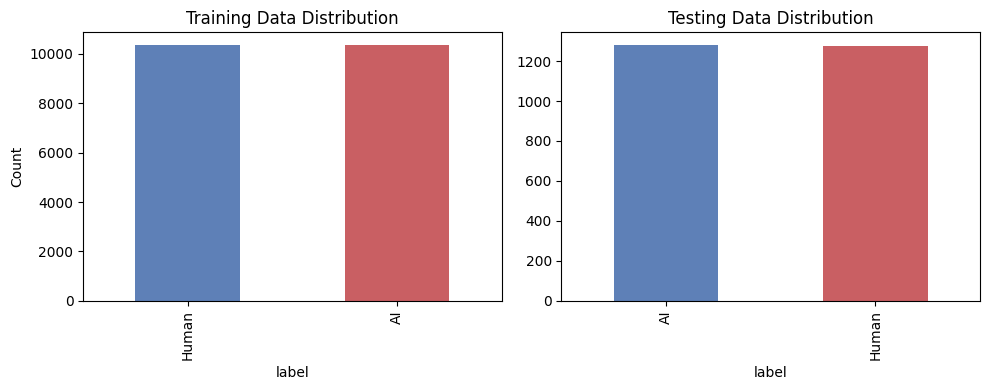

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# load TweepFake data (use ';' separator)
print("start loading TweepFake data...")
train_df = pd.read_csv("./data/train.csv", sep=';')
test_df = pd.read_csv("./data/test.csv", sep=';')

train_df.rename(columns={'text': 'Text'}, inplace=True)
test_df.rename(columns={'text': 'Text'}, inplace=True)

# map labels (Human=0, Bot=1)
label_map = {"human": 0, "bot": 1}
train_df['label'] = train_df['account.type'].str.lower().map(label_map)
test_df['label'] = test_df['account.type'].str.lower().map(label_map)

# clean missing values
train_df = train_df[['Text', 'label']].dropna()
test_df = test_df[['Text', 'label']].dropna()

# extract arrays
X_train, y_train = train_df['Text'].values, train_df['label'].values
X_test, y_test = test_df['Text'].values, test_df['label'].values

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")

# VISUALIZATION 1: Data Distribution

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# train plot
train_counts = train_df['label'].value_counts().rename(index={0: 'Human', 1: 'AI'})
train_counts.plot(kind='bar', ax=axes[0], color=['#4C72B0', '#C44E52'], alpha=0.9)
axes[0].set_title('Training Data Distribution')
axes[0].set_ylabel('Count')

# test plot
test_counts = test_df['label'].value_counts().rename(index={0: 'Human', 1: 'AI'})
test_counts.plot(kind='bar', ax=axes[1], color=['#4C72B0', '#C44E52'], alpha=0.9)
axes[1].set_title('Testing Data Distribution')

plt.tight_layout()
plt.show()

In [4]:
!pip install transformers

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.4/40.4 kB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 111.4 MB/s eta 0:00:000:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.5/645.5 kB 411.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 801.1/801.1 kB 418.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 253.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 346.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.4/108.4 kB 374.0 MB/s eta 0:00:00
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 0.36.2
    Uninstalling huggingface_hub-0.36.2:
      Successfully uninstalled huggingface_hub-0.36.2
  Consider adding this directory to PATH or, i

RoBERTa Tokenizer and DataLoader

In [5]:
import torch
import re
import numpy as np
from transformers import AutoTokenizer
from torch.utils.data import DataLoader, TensorDataset

def preprocess_for_transformer(texts, tokenizer, max_len=128):
    encoded = tokenizer(
        texts.tolist(),
        padding='max_length',
        truncation=True,
        max_length=max_len,
        return_tensors='pt'
    )
    # return ids and attention masks
    return encoded['input_ids'], encoded['attention_mask']

# feature extraction
def extract_stylo_features(text):
    text = str(text)
    chars = len(text) + 1
    words = text.split()
    word_cnt = len(words) + 1

    avg_word_len = sum(len(w) for w in words) / word_cnt
    caps_ratio = sum(1 for c in text if c.isupper()) / chars
    punc_ratio = len(re.findall(r'[!?.]', text)) / chars
    hashtag_density = text.count('#') / word_cnt
    mention_density = text.count('@') / word_cnt
    url_flag = 1.0 if 'http' in text.lower() else 0.0
    lexical_richness = len(set(words)) / word_cnt

    return [avg_word_len, caps_ratio, punc_ratio, hashtag_density, mention_density, url_flag, lexical_richness]

# tensors
model_name = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

print("extracting stylometrics and tokenizing...")
train_ids, train_masks = preprocess_for_transformer(X_train, tokenizer)
test_ids, test_masks = preprocess_for_transformer(X_test, tokenizer)

stylo_train = torch.tensor([extract_stylo_features(t) for t in X_train], dtype=torch.float)
stylo_test = torch.tensor([extract_stylo_features(t) for t in X_test], dtype=torch.float)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# DataLoaders
train_loader = DataLoader(
    TensorDataset(train_ids, train_masks, stylo_train, y_train_tensor),
    batch_size=32, shuffle=True
)
eval_loader = DataLoader(
    TensorDataset(test_ids, test_masks, stylo_test, y_test_tensor),
    batch_size=32, shuffle=False
)
print("DataLoaders ready...")

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

extracting stylometrics and tokenizing...
DataLoaders ready...


Transformer Fine-tuning Loop with **MODEL OPTIONS**

In [8]:
import torch.nn as nn
from transformers import AutoModel
from torch.optim import AdamW
import time
import datetime


# chose MODEL OPTIONS here

# 'base' | 'mean_pooling'
MODEL_MODE = 'mean_pooling'
# True | False
USE_STYLO = True
# # of features in extract_stylo_features(last cell)
STYLO_DIM = 7

class HybridSemanticRoBERTa(nn.Module):
    def __init__(self, mode='base', use_stylo=False, stylo_dim=7):
        super(HybridSemanticRoBERTa, self).__init__()
        self.mode = mode
        self.use_stylo = use_stylo
        self.roberta = AutoModel.from_pretrained("roberta-base")

        # input dimension
        # 768 (RoBERTa) + stylometrics
        self.input_dim = 768 + (stylo_dim if use_stylo else 0)

        self.classifier = nn.Sequential(
            nn.Linear(self.input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 2)
        )

    def forward(self, input_ids, attention_mask, stylo_feats):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        last_hidden = outputs.last_hidden_state

        # if pool
        if self.mode == 'base':
            pooled = last_hidden[:, 0, :]
        else:
            mask = attention_mask.unsqueeze(-1).expand(last_hidden.size()).float()
            sum_embeddings = torch.sum(last_hidden * mask, 1)
            sum_mask = torch.clamp(mask.sum(1), min=1e-9)
            pooled = sum_embeddings / sum_mask

        # if stylometrics
        if self.use_stylo:
            final_features = torch.cat((pooled, stylo_feats), dim=1)
        else:
            final_features = pooled

        return self.classifier(final_features)

# init model
device = "cuda" if torch.cuda.is_available() else "cpu"
model = HybridSemanticRoBERTa(mode=MODEL_MODE, use_stylo=USE_STYLO).to(device)
optimizer = AdamW(model.parameters(), lr=2e-5)
criterion = nn.CrossEntropyLoss()

total_start_time = time.time()

# training Loop
print(f"running: [Mode: {MODEL_MODE}] [Stylo: {USE_STYLO}] on {device}...")
for epoch in range(3):
    model.train()
    total_loss = 0
    for batch in train_loader:
        b_ids, b_masks, b_stylo, b_labels = [t.to(device) for t in batch]
        optimizer.zero_grad()
        logits = model(b_ids, b_masks, b_stylo)
        loss = criterion(logits, b_labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"epoch {epoch+1}, loss: {total_loss/len(train_loader):.4f}")

# Calculate total training time
total_elapsed = time.time() - total_start_time
total_time_formatted = str(datetime.timedelta(seconds=int(total_elapsed)))
print(f"\nTraining Complete! Total Elapsed Time: {total_time_formatted}")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


running: [Mode: mean_pooling] [Stylo: True] on cuda...
epoch 1, loss: 0.2983
epoch 2, loss: 0.1923
epoch 3, loss: 0.1269

Training Complete! Total Elapsed Time: 0:05:17


Evaluation

start evaluation on test set [Mode: mean_pooling] [Stylo: True]...

-------------------------------------------------------
STRATEGY A: HIGH PRECISION (Threshold 0.5)
Goal: minimal false bans of human accounts
-------------------------------------------------------
AUC-ROC:   0.9737
F1-Score:  0.9094
Precision: 0.8979
Recall:    0.9211

Detailed Report:
              precision    recall  f1-score   support

   Human (0)       0.92      0.90      0.91      1278
      AI (1)       0.90      0.92      0.91      1280

    accuracy                           0.91      2558
   macro avg       0.91      0.91      0.91      2558
weighted avg       0.91      0.91      0.91      2558


-------------------------------------------------------
STRATEGY B: HIGH RECALL (Threshold 0.1)
Goal: catch maximum potential AI accounts
-------------------------------------------------------
AUC-ROC:   0.9737
F1-Score:  0.8910
Precision: 0.8187
Recall:    0.9773

Detailed Report:
              precision    recal

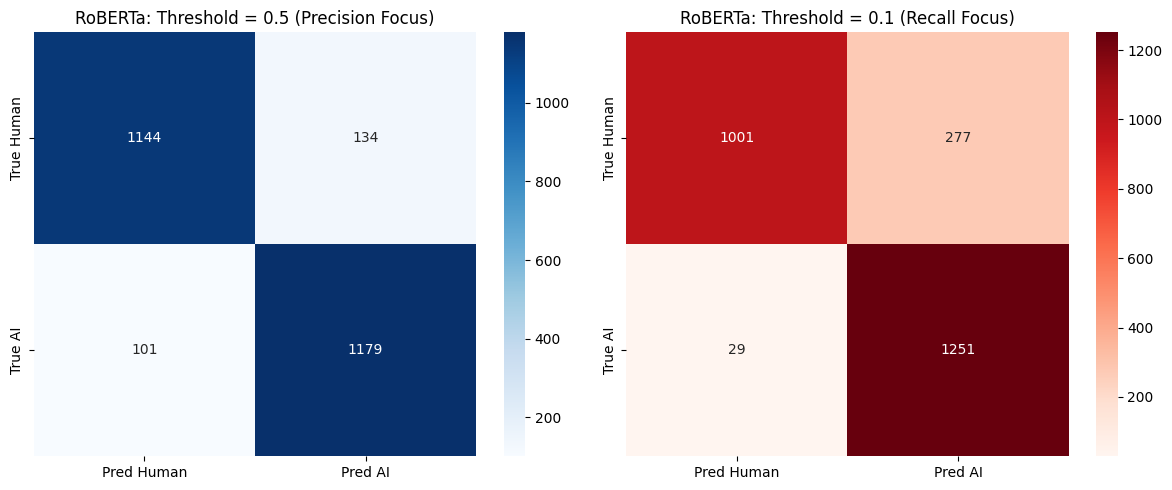

In [10]:
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score, classification_report, confusion_matrix

model.eval()
all_probs = []

print(f"start evaluation on test set [Mode: {MODEL_MODE}] [Stylo: {USE_STYLO}]...")

with torch.no_grad():
    for batch in eval_loader:
        b_input_ids, b_input_mask, b_stylo, _ = [t.to(device) for t in batch]
        outputs = model(b_input_ids, b_input_mask, b_stylo)

        probs = torch.softmax(outputs, dim=1)[:, 1]
        all_probs.extend(probs.cpu().numpy())

all_probs = torch.tensor(all_probs)
y_test_tensor = y_test_tensor.cpu()
global_auc = roc_auc_score(y_test_tensor, all_probs)

# EVALUATION A: High Precision (Threshold 0.5)
thresh_A = 0.5
preds_A = (all_probs > thresh_A).long()
cm_A = confusion_matrix(y_test_tensor, preds_A)

print("\n" + "-"*55)
print(f"STRATEGY A: HIGH PRECISION (Threshold {thresh_A})")
print("Goal: minimal false bans of human accounts")
print("-" * 55)
print(f"AUC-ROC:   {global_auc:.4f}")
print(f"F1-Score:  {f1_score(y_test_tensor, preds_A):.4f}")
print(f"Precision: {precision_score(y_test_tensor, preds_A):.4f}")
print(f"Recall:    {recall_score(y_test_tensor, preds_A):.4f}")
print("\nDetailed Report:")
print(classification_report(y_test_tensor, preds_A, target_names=['Human (0)', 'AI (1)']))

# EVALUATION B: High Recall (Threshold 0.1)
thresh_B = 0.1
preds_B = (all_probs > thresh_B).long()
cm_B = confusion_matrix(y_test_tensor, preds_B)

print("\n" + "-"*55)
print(f"STRATEGY B: HIGH RECALL (Threshold {thresh_B})")
print("Goal: catch maximum potential AI accounts")
print("-" * 55)
print(f"AUC-ROC:   {global_auc:.4f}")
print(f"F1-Score:  {f1_score(y_test_tensor, preds_B):.4f}")
print(f"Precision: {precision_score(y_test_tensor, preds_B):.4f}")
print(f"Recall:    {recall_score(y_test_tensor, preds_B):.4f}")
print("\nDetailed Report:")
print(classification_report(y_test_tensor, preds_B, target_names=['Human (0)', 'AI (1)']))

# VISUALIZATION: Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_A, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Pred Human', 'Pred AI'], yticklabels=['True Human', 'True AI'])
axes[0].set_title(f'RoBERTa: Threshold = {thresh_A} (Precision Focus)')

sns.heatmap(cm_B, annot=True, fmt='d', cmap='Reds', ax=axes[1],
            xticklabels=['Pred Human', 'Pred AI'], yticklabels=['True Human', 'True AI'])
axes[1].set_title(f'RoBERTa: Threshold = {thresh_B} (Recall Focus)')

plt.tight_layout()
plt.show()

## Evaluating on BotSim-24 dataset using trainied model

Start loading BotSim-24 data...
Train size: 2324 | Test size: 582


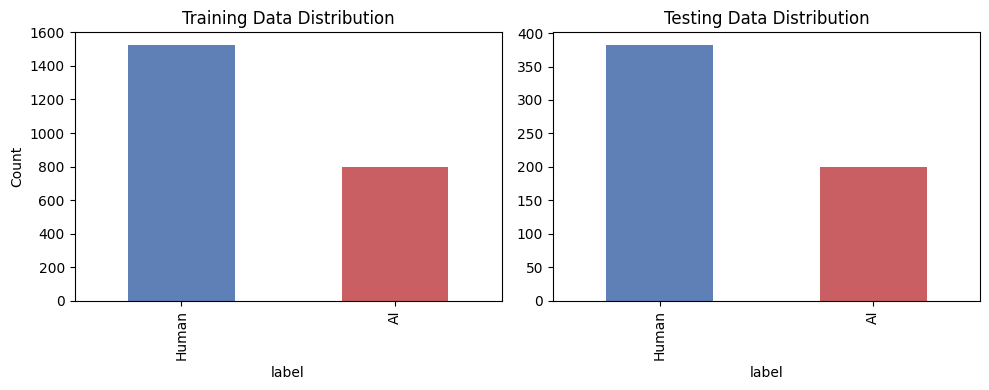

In [11]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

print("Start loading BotSim-24 data...")

# 1. Load the Users metadata
users_df = pd.read_csv('./data/Users.csv')

# According to the BotSim-24 README, the dataset is ordered:
# First 1,907 are human (0), last 1,000 are bots (1)
labels = [0] * 1907 + [1] * 1000

# Safety check in case your CSV size varies slightly
if len(users_df) == len(labels):
    users_df['label'] = labels
else:
    # Fallback: if it's not exactly 2907, we'll try to guess based on 'character_setting' 
    # since only bot accounts contain this information.
    users_df['label'] = users_df['character_setting'].notna().astype(int)

# 2. Load the JSON data containing texts
with open('./data/user_post_comment.json', 'r') as f:
    posts_data = json.load(f)

# 3. Extract the textual sequence T = {t1, t2, ..., tn} for each user
dataset = []
for idx, row in users_df.iterrows():
    user_id = row['user_id']
    label = row['label']
    
    if user_id in posts_data:
        user_content = posts_data[user_id]
        texts = []
        
        # Extract submissions (posts)
        if 'posts' in user_content:
            for p in user_content['posts']:
                if 'posts' in p and pd.notna(p['posts']):
                    texts.append(str(p['posts']))
                    
        # Extract level 1 comments
        if 'comment_1' in user_content:
            for c in user_content['comment_1']:
                if 'comment_body' in c and pd.notna(c['comment_body']):
                    texts.append(str(c['comment_body']))
                    
        # Extract level 2 comments
        if 'comment_2' in user_content:
            for c in user_content['comment_2']:
                if 'comment_body' in c and pd.notna(c['comment_body']):
                    texts.append(str(c['comment_body']))
                    
        # Join all texts into a single sequence for this user separated by spaces
        full_text = " ".join(texts)
        
        # Only add to dataset if the user actually has text
        if len(full_text.strip()) > 0:
            dataset.append({'Text': full_text, 'label': label})

# 4. Create the final DataFrame
df = pd.DataFrame(dataset)

# 5. Split into train and test (stratified to maintain the Human/Bot ratio)
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

# Extract arrays for the Tokenizer & DataLoader cell
X_train, y_train = train_df['Text'].values, train_df['label'].values
X_test, y_test = test_df['Text'].values, test_df['label'].values

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")

# VISUALIZATION: Data Distribution
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# train plot
train_counts = train_df['label'].value_counts().rename(index={0: 'Human', 1: 'AI'})
train_counts.plot(kind='bar', ax=axes[0], color=['#4C72B0', '#C44E52'], alpha=0.9)
axes[0].set_title('Training Data Distribution')
axes[0].set_ylabel('Count')

# test plot
test_counts = test_df['label'].value_counts().rename(index={0: 'Human', 1: 'AI'})
test_counts.plot(kind='bar', ax=axes[1], color=['#4C72B0', '#C44E52'], alpha=0.9)
axes[1].set_title('Testing Data Distribution')

plt.tight_layout()
plt.show()

--- CROSS-DOMAIN EVALUATION: TweepFake Model on BotSim-24 ---
Extracting stylometrics and tokenizing BotSim-24 data...
Running Inference on 2906 accounts...

ZERO-SHOT PERFORMANCE ON BOTSIM-24 (Threshold 0.5)
AUC-ROC:   0.0930
F1-Score:  0.0097
Precision: 0.0158
Recall:    0.0070

Detailed Report:
              precision    recall  f1-score   support

   Human (0)       0.60      0.77      0.67      1906
      AI (1)       0.02      0.01      0.01      1000

    accuracy                           0.51      2906
   macro avg       0.31      0.39      0.34      2906
weighted avg       0.40      0.51      0.44      2906



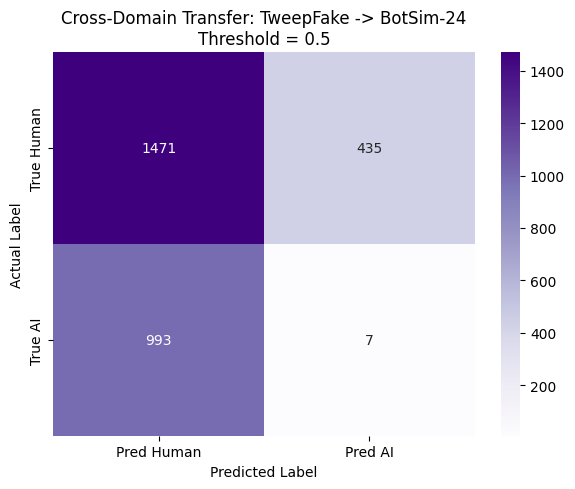


ZERO-SHOT PERFORMANCE ON BOTSIM-24 (Threshold 0.1)
AUC-ROC:   0.0930
F1-Score:  0.0370
Precision: 0.0343
Recall:    0.0400

Detailed Report:
              precision    recall  f1-score   support

   Human (0)       0.45      0.41      0.43      1906
      AI (1)       0.03      0.04      0.04      1000

    accuracy                           0.28      2906
   macro avg       0.24      0.22      0.23      2906
weighted avg       0.31      0.28      0.29      2906



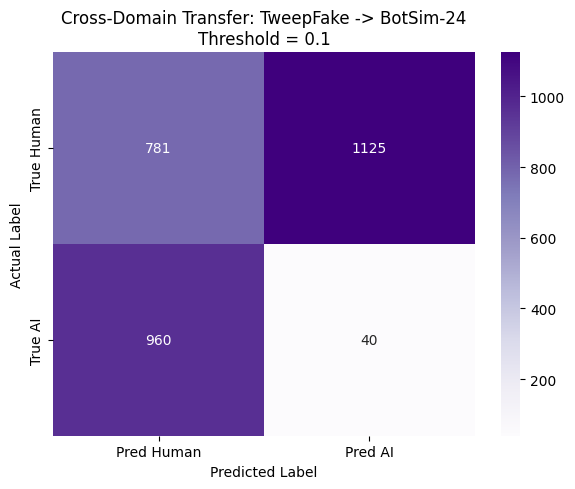

In [14]:
print("--- CROSS-DOMAIN EVALUATION: TweepFake Model on BotSim-24 ---")

# 1. Prepare the entire BotSim-24 dataset for evaluation
# We use the full 'df' from the previous cell because the model has never seen ANY of it.
botsim_texts = df['Text'].values
botsim_labels = df['label'].values

print("Extracting stylometrics and tokenizing BotSim-24 data...")
botsim_ids, botsim_masks = preprocess_for_transformer(botsim_texts, tokenizer)
botsim_stylo = torch.tensor([extract_stylo_features(t) for t in botsim_texts], dtype=torch.float)
botsim_labels_tensor = torch.tensor(botsim_labels, dtype=torch.long)

botsim_loader = DataLoader(
    TensorDataset(botsim_ids, botsim_masks, botsim_stylo, botsim_labels_tensor),
    batch_size=32, shuffle=False
)

# 2. Run Evaluation
model.eval()
all_probs_botsim = []

print(f"Running Inference on {len(botsim_texts)} accounts...")
with torch.no_grad():
    for batch in botsim_loader:
        b_input_ids, b_input_mask, b_stylo, _ = [t.to(device) for t in batch]
        
        # Pass inputs based on your MODEL_OPTIONS
        outputs = model(b_input_ids, b_input_mask, b_stylo)
        probs = torch.softmax(outputs, dim=1)[:, 1]
        all_probs_botsim.extend(probs.cpu().numpy())

all_probs_botsim = torch.tensor(all_probs_botsim)
botsim_labels_tensor = botsim_labels_tensor.cpu()

# Calculate global AUC-ROC
botsim_auc = roc_auc_score(botsim_labels_tensor, all_probs_botsim)

# 3. Apply Decision Thresholds (Testing both Strict and Lenient strategies)
thresh_A = 0.5
preds_A = (all_probs_botsim > thresh_A).long()
cm_A = confusion_matrix(botsim_labels_tensor, preds_A)

print("\n" + "="*55)
print(f"ZERO-SHOT PERFORMANCE ON BOTSIM-24 (Threshold {thresh_A})")
print("=" * 55)
print(f"AUC-ROC:   {botsim_auc:.4f}")
print(f"F1-Score:  {f1_score(botsim_labels_tensor, preds_A):.4f}")
print(f"Precision: {precision_score(botsim_labels_tensor, preds_A):.4f}")
print(f"Recall:    {recall_score(botsim_labels_tensor, preds_A):.4f}")
print("\nDetailed Report:")
print(classification_report(botsim_labels_tensor, preds_A, target_names=['Human (0)', 'AI (1)']))

# 4. Visualize the Cross-Domain Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_A, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Pred Human', 'Pred AI'], yticklabels=['True Human', 'True AI'])
plt.title(f'Cross-Domain Transfer: TweepFake -> BotSim-24\nThreshold = {thresh_A}')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()


# 4. Apply Decision Thresholds (Testing both Strict and Lenient strategies)
thresh_B = 0.1
preds_B = (all_probs_botsim > thresh_B).long()
cm_A = confusion_matrix(botsim_labels_tensor, preds_B)

print("\n" + "="*55)
print(f"ZERO-SHOT PERFORMANCE ON BOTSIM-24 (Threshold {thresh_B})")
print("=" * 55)
print(f"AUC-ROC:   {botsim_auc:.4f}")
print(f"F1-Score:  {f1_score(botsim_labels_tensor, preds_B):.4f}")
print(f"Precision: {precision_score(botsim_labels_tensor, preds_B):.4f}")
print(f"Recall:    {recall_score(botsim_labels_tensor, preds_B):.4f}")
print("\nDetailed Report:")
print(classification_report(botsim_labels_tensor, preds_B, target_names=['Human (0)', 'AI (1)']))

# 4. Visualize the Cross-Domain Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_A, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Pred Human', 'Pred AI'], yticklabels=['True Human', 'True AI'])
plt.title(f'Cross-Domain Transfer: TweepFake -> BotSim-24\nThreshold = {thresh_B}')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## Retrain Model on BOTSIM-24

In [15]:
print("--- PREPARING BOTSIM-24 FOR TRAINING ---")

# 1. Tokenize and Extract Stylometrics for BotSim-24
print("Extracting stylometrics and tokenizing...")
train_ids_bs, train_masks_bs = preprocess_for_transformer(X_train, tokenizer)
test_ids_bs, test_masks_bs = preprocess_for_transformer(X_test, tokenizer)

stylo_train_bs = torch.tensor([extract_stylo_features(t) for t in X_train], dtype=torch.float)
stylo_test_bs = torch.tensor([extract_stylo_features(t) for t in X_test], dtype=torch.float)

y_train_tensor_bs = torch.tensor(y_train, dtype=torch.long)
y_test_tensor_bs = torch.tensor(y_test, dtype=torch.long)

# 2. Create BotSim-24 DataLoaders
train_loader_bs = DataLoader(
    TensorDataset(train_ids_bs, train_masks_bs, stylo_train_bs, y_train_tensor_bs),
    batch_size=32, shuffle=True
)
eval_loader_bs = DataLoader(
    TensorDataset(test_ids_bs, test_masks_bs, stylo_test_bs, y_test_tensor_bs),
    batch_size=32, shuffle=False
)
print("DataLoaders ready.")

# ==========================================
# 3. INITIALIZE A FRESH MODEL
# ==========================================
device = "cuda" if torch.cuda.is_available() else "cpu"
# Re-instantiating the model clears the TweepFake weights
model_bs = HybridSemanticRoBERTa(mode=MODEL_MODE, use_stylo=USE_STYLO).to(device)
optimizer_bs = AdamW(model_bs.parameters(), lr=2e-5)
criterion = nn.CrossEntropyLoss()

# ==========================================
# 4. TRAINING LOOP
# ==========================================
print(f"\nTraining on BotSim-24: [Mode: {MODEL_MODE}] [Stylo: {USE_STYLO}] on {device}...")
total_start_time = time.time()

for epoch in range(3): # Adjust epochs if necessary based on convergence
    epoch_start_time = time.time()
    model_bs.train()
    total_loss = 0
    
    for batch in train_loader_bs:
        b_ids, b_masks, b_stylo, b_labels = [t.to(device) for t in batch]
        
        optimizer_bs.zero_grad()
        logits = model_bs(b_ids, b_masks, b_stylo)
        loss = criterion(logits, b_labels)
        loss.backward()
        optimizer_bs.step()
        
        total_loss += loss.item()
        
    epoch_elapsed = time.time() - epoch_start_time
    epoch_time_formatted = str(datetime.timedelta(seconds=int(epoch_elapsed)))
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader_bs):.4f} | Time: {epoch_time_formatted}")

total_elapsed = time.time() - total_start_time
print(f"Training Complete! Total Time: {str(datetime.timedelta(seconds=int(total_elapsed)))}")

--- PREPARING BOTSIM-24 FOR TRAINING ---
Extracting stylometrics and tokenizing...
DataLoaders ready.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Training on BotSim-24: [Mode: mean_pooling] [Stylo: True] on cuda...
Epoch 1, Loss: 0.1488 | Time: 0:00:11
Epoch 2, Loss: 0.0154 | Time: 0:00:11
Epoch 3, Loss: 0.0143 | Time: 0:00:11
Training Complete! Total Time: 0:00:35


### Re evaluate


--- EVALUATING ON BOTSIM-24 TEST SET ---
AUC-ROC:   1.0000
F1-Score:  1.0000
Precision: 1.0000
Recall:    1.0000

Detailed Report:
              precision    recall  f1-score   support

   Human (0)       1.00      1.00      1.00       382
      AI (1)       1.00      1.00      1.00       200

    accuracy                           1.00       582
   macro avg       1.00      1.00      1.00       582
weighted avg       1.00      1.00      1.00       582



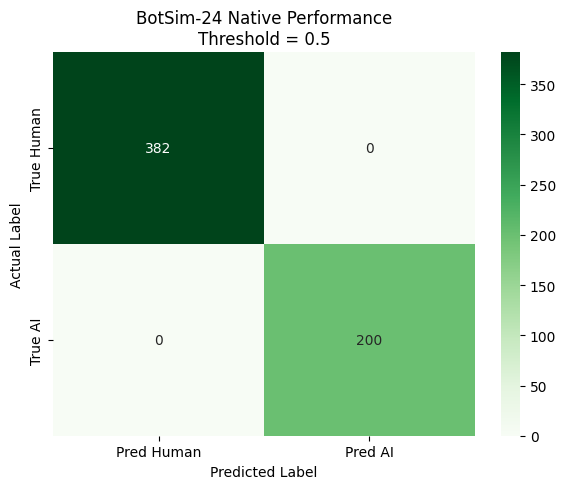


--- EVALUATING ON BOTSIM-24 TEST SET ---
AUC-ROC:   1.0000
F1-Score:  1.0000
Precision: 1.0000
Recall:    1.0000

Detailed Report:
              precision    recall  f1-score   support

   Human (0)       1.00      1.00      1.00       382
      AI (1)       1.00      1.00      1.00       200

    accuracy                           1.00       582
   macro avg       1.00      1.00      1.00       582
weighted avg       1.00      1.00      1.00       582



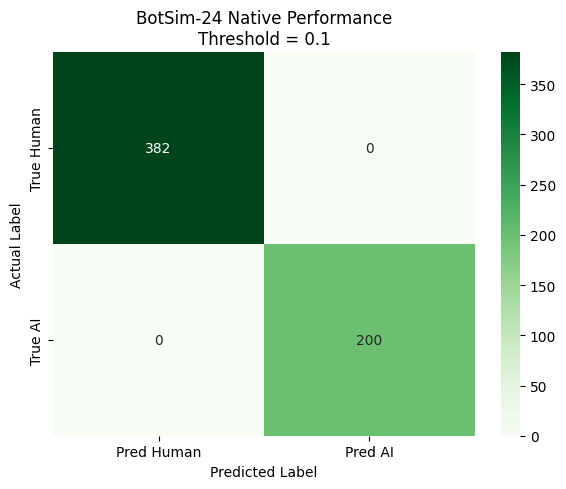

In [17]:
print("\n--- EVALUATING ON BOTSIM-24 TEST SET ---")
model_bs.eval()
all_probs_bs = []

with torch.no_grad():
    for batch in eval_loader_bs:
        b_input_ids, b_input_mask, b_stylo, _ = [t.to(device) for t in batch]
        outputs = model_bs(b_input_ids, b_input_mask, b_stylo)
        probs = torch.softmax(outputs, dim=1)[:, 1]
        all_probs_bs.extend(probs.cpu().numpy())

all_probs_bs = torch.tensor(all_probs_bs)
y_test_tensor_bs = y_test_tensor_bs.cpu()

# Calculate Metrics (Using Threshold 0.5 as standard)
auc_bs = roc_auc_score(y_test_tensor_bs, all_probs_bs)
thresh = 0.5
preds_bs = (all_probs_bs > thresh).long()
cm_bs = confusion_matrix(y_test_tensor_bs, preds_bs)

print(f"AUC-ROC:   {auc_bs:.4f}")
print(f"F1-Score:  {f1_score(y_test_tensor_bs, preds_bs):.4f}")
print(f"Precision: {precision_score(y_test_tensor_bs, preds_bs):.4f}")
print(f"Recall:    {recall_score(y_test_tensor_bs, preds_bs):.4f}")
print("\nDetailed Report:")
print(classification_report(y_test_tensor_bs, preds_bs, target_names=['Human (0)', 'AI (1)']))

# Confusion Matrix Visualization
plt.figure(figsize=(6, 5))
sns.heatmap(cm_bs, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Pred Human', 'Pred AI'], yticklabels=['True Human', 'True AI'])
plt.title(f'BotSim-24 Native Performance\nThreshold = {thresh}')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()



# --------------------------------------------------------------

print("\n--- EVALUATING ON BOTSIM-24 TEST SET ---")
model_bs.eval()
all_probs_bs = []

with torch.no_grad():
    for batch in eval_loader_bs:
        b_input_ids, b_input_mask, b_stylo, _ = [t.to(device) for t in batch]
        outputs = model_bs(b_input_ids, b_input_mask, b_stylo)
        probs = torch.softmax(outputs, dim=1)[:, 1]
        all_probs_bs.extend(probs.cpu().numpy())

all_probs_bs = torch.tensor(all_probs_bs)
y_test_tensor_bs = y_test_tensor_bs.cpu()

# Calculate Metrics (Using Threshold 0.5 as standard)
auc_bs = roc_auc_score(y_test_tensor_bs, all_probs_bs)
thresh = 0.1
preds_bs = (all_probs_bs > thresh).long()
cm_bs = confusion_matrix(y_test_tensor_bs, preds_bs)

print(f"AUC-ROC:   {auc_bs:.4f}")
print(f"F1-Score:  {f1_score(y_test_tensor_bs, preds_bs):.4f}")
print(f"Precision: {precision_score(y_test_tensor_bs, preds_bs):.4f}")
print(f"Recall:    {recall_score(y_test_tensor_bs, preds_bs):.4f}")
print("\nDetailed Report:")
print(classification_report(y_test_tensor_bs, preds_bs, target_names=['Human (0)', 'AI (1)']))

# Confusion Matrix Visualization
plt.figure(figsize=(6, 5))
sns.heatmap(cm_bs, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Pred Human', 'Pred AI'], yticklabels=['True Human', 'True AI'])
plt.title(f'BotSim-24 Native Performance\nThreshold = {thresh}')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

### Evalueate that 

--- REVERSE CROSS-DOMAIN EVALUATION: BotSim-24 Model on TweepFake ---
Loading TweepFake test data...
Extracting stylometrics and tokenizing TweepFake data...
Running Inference on 2558 TweepFake accounts...

REVERSE ZERO-SHOT PERFORMANCE: BotSim-24 -> TweepFake
AUC-ROC:   0.3728
F1-Score:  0.0062
Precision: 0.2105
Recall:    0.0031

Detailed Report:
              precision    recall  f1-score   support

   Human (0)       0.50      0.99      0.66      1278
      AI (1)       0.21      0.00      0.01      1280

    accuracy                           0.50      2558
   macro avg       0.35      0.50      0.33      2558
weighted avg       0.35      0.50      0.33      2558



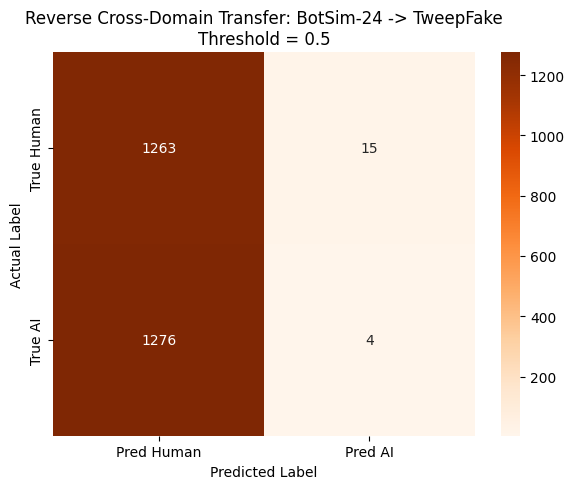


REVERSE ZERO-SHOT PERFORMANCE: BotSim-24 -> TweepFake
AUC-ROC:   0.3728
F1-Score:  0.0091
Precision: 0.1667
Recall:    0.0047

Detailed Report:
              precision    recall  f1-score   support

   Human (0)       0.49      0.98      0.66      1278
      AI (1)       0.17      0.00      0.01      1280

    accuracy                           0.49      2558
   macro avg       0.33      0.49      0.33      2558
weighted avg       0.33      0.49      0.33      2558



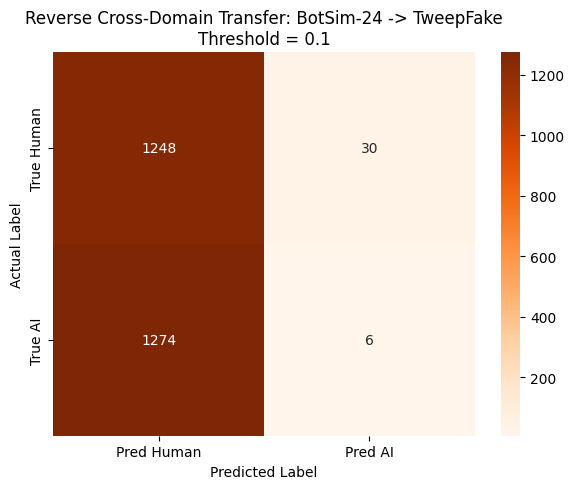

In [19]:
print("--- REVERSE CROSS-DOMAIN EVALUATION: BotSim-24 Model on TweepFake ---")

# 1. Reload the TweepFake test set cleanly
print("Loading TweepFake test data...")
tweep_test_df = pd.read_csv('./data/test.csv', sep=';')

# Clean and map the TweepFake labels (Human = 0, Bot = 1)
label_map = {"human": 0, "bot": 1}
tweep_test_df['label'] = tweep_test_df['account.type'].str.lower().map(label_map)
tweep_test_df.rename(columns={'text': 'Text'}, inplace=True)
tweep_test_df = tweep_test_df[['Text', 'label']].dropna()

tweep_texts = tweep_test_df['Text'].values
tweep_labels = tweep_test_df['label'].values

# 2. Tokenize and extract stylometrics for TweepFake
print("Extracting stylometrics and tokenizing TweepFake data...")
tweep_ids, tweep_masks = preprocess_for_transformer(tweep_texts, tokenizer)
tweep_stylo = torch.tensor([extract_stylo_features(t) for t in tweep_texts], dtype=torch.float)
tweep_labels_tensor = torch.tensor(tweep_labels, dtype=torch.long)

# Create the DataLoader
tweep_loader = DataLoader(
    TensorDataset(tweep_ids, tweep_masks, tweep_stylo, tweep_labels_tensor),
    batch_size=32, shuffle=False
)

# ==========================================
# 3. RUN INFERENCE USING THE BOTSIM-24 MODEL (model_bs)
# ==========================================
model_bs.eval()
all_probs_tweep = []

print(f"Running Inference on {len(tweep_texts)} TweepFake accounts...")
with torch.no_grad():
    for batch in tweep_loader:
        b_input_ids, b_input_mask, b_stylo, _ = [t.to(device) for t in batch]
        
        # NOTE: We are explicitly using model_bs here!
        outputs = model_bs(b_input_ids, b_input_mask, b_stylo)
        probs = torch.softmax(outputs, dim=1)[:, 1]
        all_probs_tweep.extend(probs.cpu().numpy())

all_probs_tweep = torch.tensor(all_probs_tweep)
tweep_labels_tensor = tweep_labels_tensor.cpu()

# ==========================================
# 4. METRICS & VISUALIZATION
# ==========================================
tweep_auc = roc_auc_score(tweep_labels_tensor, all_probs_tweep)
thresh = 0.5
preds_tweep = (all_probs_tweep > thresh).long()
cm_tweep = confusion_matrix(tweep_labels_tensor, preds_tweep)

print("\n" + "="*55)
print(f"REVERSE ZERO-SHOT PERFORMANCE: BotSim-24 -> TweepFake")
print("=" * 55)
print(f"AUC-ROC:   {tweep_auc:.4f}")
print(f"F1-Score:  {f1_score(tweep_labels_tensor, preds_tweep):.4f}")
print(f"Precision: {precision_score(tweep_labels_tensor, preds_tweep):.4f}")
print(f"Recall:    {recall_score(tweep_labels_tensor, preds_tweep):.4f}")
print("\nDetailed Report:")
print(classification_report(tweep_labels_tensor, preds_tweep, target_names=['Human (0)', 'AI (1)']))

# Confusion Matrix Visualization
plt.figure(figsize=(6, 5))
sns.heatmap(cm_tweep, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Pred Human', 'Pred AI'], yticklabels=['True Human', 'True AI'])
plt.title(f'Reverse Cross-Domain Transfer: BotSim-24 -> TweepFake\nThreshold = {thresh}')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()


tweep_auc = roc_auc_score(tweep_labels_tensor, all_probs_tweep)
thresh = 0.1
preds_tweep = (all_probs_tweep > thresh).long()
cm_tweep = confusion_matrix(tweep_labels_tensor, preds_tweep)

print("\n" + "="*55)
print(f"REVERSE ZERO-SHOT PERFORMANCE: BotSim-24 -> TweepFake")
print("=" * 55)
print(f"AUC-ROC:   {tweep_auc:.4f}")
print(f"F1-Score:  {f1_score(tweep_labels_tensor, preds_tweep):.4f}")
print(f"Precision: {precision_score(tweep_labels_tensor, preds_tweep):.4f}")
print(f"Recall:    {recall_score(tweep_labels_tensor, preds_tweep):.4f}")
print("\nDetailed Report:")
print(classification_report(tweep_labels_tensor, preds_tweep, target_names=['Human (0)', 'AI (1)']))

# Confusion Matrix Visualization
plt.figure(figsize=(6, 5))
sns.heatmap(cm_tweep, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Pred Human', 'Pred AI'], yticklabels=['True Human', 'True AI'])
plt.title(f'Reverse Cross-Domain Transfer: BotSim-24 -> TweepFake\nThreshold = {thresh}')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()